# Credit Risk Modeling & Scorecard Development

## Project Objective

The objective of this project is to build a credit risk model that predicts the probability of loan default and segments borrowers into different risk categories.

The project uses Logistic Regression to estimate Probability of Default (PD) and evaluates model performance using AUC, KS, and Gini metrics.

A credit risk scorecard and borrower risk segmentation framework will be developed to classify customers into Low, Medium, and High Risk categories.
    

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

print("Libraries imported successfully")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully


In [6]:
import os

os.getcwd()

'/Users/sheileshrajtandi/risk-projects'

In [7]:
df = pd.read_csv("credit_risk_dataset.csv")

print("Dataset loaded successfully")
print("Rows and Columns:", df.shape)

df.head()

Dataset loaded successfully
Rows and Columns: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [8]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (32581, 12)

Column Names:
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 3

In [9]:
df.head(10)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


In [10]:
df["loan_status"].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [11]:
df["loan_status"].value_counts(normalize=True) * 100

loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

## Data Quality Checks

The dataset is evaluated for missing values, duplicate records, and potential data quality issues before model development.

In [12]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(165)

In [14]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### Duplicate Handling

The dataset contained 165 duplicate records. Exact duplicates were removed to prevent repeated observations from influencing model training and evaluation.

In [15]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)
print("Remaining duplicates:", df.duplicated().sum())

Dataset shape after removing duplicates: (32416, 12)
Remaining duplicates: 0


### Missing Value Treatment

Missing values in employment length and loan interest rate were imputed using the median. Median imputation was selected because it is less sensitive to extreme values and preserves observations for model development.

In [16]:
df["person_emp_length"] = df["person_emp_length"].fillna(
    df["person_emp_length"].median()
)

df["loan_int_rate"] = df["loan_int_rate"].fillna(
    df["loan_int_rate"].median()
)

print("Remaining missing values:")
print(df.isnull().sum())

Remaining missing values:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


## Outlier and Data Validity Analysis

Numeric borrower and loan variables are analyzed to identify extreme or potentially unrealistic values that may distort model development.

In [17]:
numeric_columns = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32416.0,27.747008,6.354100,20.00,23.00,26.00,30.00,144.00
person_income,32416.0,66091.640826,62015.580269,4000.00,38542.00,55000.00,79218.00,6000000.00
person_emp_length,32416.0,4.768880,4.090411,0.00,2.00,4.00,7.00,123.00
loan_amnt,32416.0,9593.845632,6322.730241,500.00,5000.00,8000.00,12250.00,35000.00
loan_int_rate,32416.0,11.014662,3.083050,5.42,8.49,10.99,13.11,23.22
loan_percent_income,32416.0,0.170250,0.106812,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32416.0,5.811297,4.059030,2.00,3.00,4.00,8.00,30.00


In [18]:
for column in numeric_columns:
    print(column)
    print("Minimum:", df[column].min())
    print("Maximum:", df[column].max())
    print("-" * 30)

person_age
Minimum: 20
Maximum: 144
------------------------------
person_income
Minimum: 4000
Maximum: 6000000
------------------------------
person_emp_length
Minimum: 0.0
Maximum: 123.0
------------------------------
loan_amnt
Minimum: 500
Maximum: 35000
------------------------------
loan_int_rate
Minimum: 5.42
Maximum: 23.22
------------------------------
loan_percent_income
Minimum: 0.0
Maximum: 0.83
------------------------------
cb_person_cred_hist_length
Minimum: 2
Maximum: 30
------------------------------


In [19]:
suspicious_records = df[
    (df["person_age"] > 100) |
    (df["person_emp_length"] > df["person_age"] - 18)
]

print("Suspicious records:", suspicious_records.shape[0])

suspicious_records[
    [
        "person_age",
        "person_income",
        "person_emp_length",
        "loan_amnt",
        "loan_status"
    ]
]

Suspicious records: 7836


,person_age,person_income,person_emp_length,loan_amnt,loan_status
0,22,59000,123.0,35000,1
1,21,9600,5.0,1000,0
4,24,54400,8.0,35000,1
8,24,83000,8.0,35000,1
9,21,10000,6.0,1600,1
...,...,...,...,...,...
32280,36,53800,20.0,18200,1
32286,36,48686,21.0,12000,0
32288,38,99996,22.0,25000,0
32297,144,6000000,12.0,5000,0


### Treatment of Invalid Extreme Values

Domain-based validity checks identified unrealistic borrower ages above 100 years and employment tenure above 60 years. These records were treated as invalid data points and removed before model development. Other high numeric values were retained unless they violated a clear business validity rule.

In [20]:
invalid_records = df[
    (df["person_age"] > 100) |
    (df["person_emp_length"] > 60)
]

print("Invalid records identified:", invalid_records.shape[0])

invalid_records[
    [
        "person_age",
        "person_income",
        "person_emp_length",
        "loan_amnt",
        "loan_status"
    ]
]

Invalid records identified: 7


,person_age,person_income,person_emp_length,loan_amnt,loan_status
0,22,59000,123.0,35000,1
81,144,250000,4.0,4800,0
183,144,200000,4.0,6000,0
210,21,192000,123.0,20000,0
575,123,80004,2.0,20400,0
747,123,78000,7.0,20000,0
32297,144,6000000,12.0,5000,0


### Invalid Record Removal

Seven records containing clearly unrealistic borrower age or employment tenure values were identified using domain-based validity rules. These records were removed to prevent extreme data errors from influencing model development.

In [21]:
df = df[
    (df["person_age"] <= 100) &
    (df["person_emp_length"] <= 60)
].copy()

print("Dataset shape after removing invalid records:", df.shape)

print("Maximum age:", df["person_age"].max())
print("Maximum employment length:", df["person_emp_length"].max())

Dataset shape after removing invalid records: (32409, 12)
Maximum age: 94
Maximum employment length: 41.0


## Exploratory Data Analysis

The cleaned dataset is analyzed to identify borrower and loan characteristics associated with higher default rates. Default patterns are evaluated across loan grade, home ownership, loan purpose, interest rate, and loan-to-income ratio.

In [31]:
grade_default = (
    df.groupby("loan_grade")["loan_status"]
    .agg(["count", "mean"])
    .reset_index()
)

grade_default["default_rate"] = (
    grade_default["mean"] * 100
).round(2)

grade_default = grade_default.sort_values("loan_grade")

grade_default[
    [
        "loan_grade",
        "count",
        "default_rate"
    ]
]

,loan_grade,count,default_rate
0,A,10702,9.96
1,B,10384,16.32
2,C,6436,20.76
3,D,3619,59.05
4,E,963,64.49
5,F,241,70.54
6,G,64,98.44


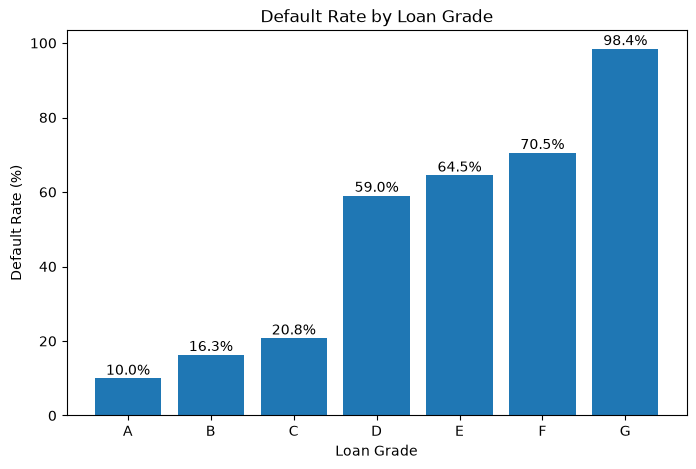

In [24]:
plt.figure(figsize=(8,5))

plt.bar(
    grade_default["loan_grade"],
    grade_default["default_rate"]
)

plt.xlabel("Loan Grade")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Loan Grade")

for i, value in enumerate(grade_default["default_rate"]):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

### Key Business Insight

Default rates increased consistently from Grade A to Grade G, demonstrating a clear risk gradient across loan grades. Higher loan grades exhibited substantially higher observed default rates, indicating that loan grade is one of the strongest predictors of borrower credit risk in this dataset.

### Business Recommendation

Loan grade should be retained as a primary predictive feature because it effectively differentiates low-risk and high-risk borrowers. The strong relationship between loan grade and observed default behavior suggests it will contribute significantly to the credit risk model's ability to estimate Probability of Default (PD).

### Home Ownership Analysis

Default rates are analyzed across different home ownership categories to understand whether housing status influences borrower repayment behavior.

In [32]:
home_default = (
    df.groupby("person_home_ownership")["loan_status"]
    .agg(["count", "mean"])
    .reset_index()
)

home_default["default_rate"] = (
    home_default["mean"] * 100
).round(2)

home_default[
    [
        "person_home_ownership",
        "count",
        "default_rate"
    ]
]

,person_home_ownership,count,default_rate
0,MORTGAGE,13366,12.62
1,OTHER,106,31.13
2,OWN,2563,7.49
3,RENT,16374,31.61


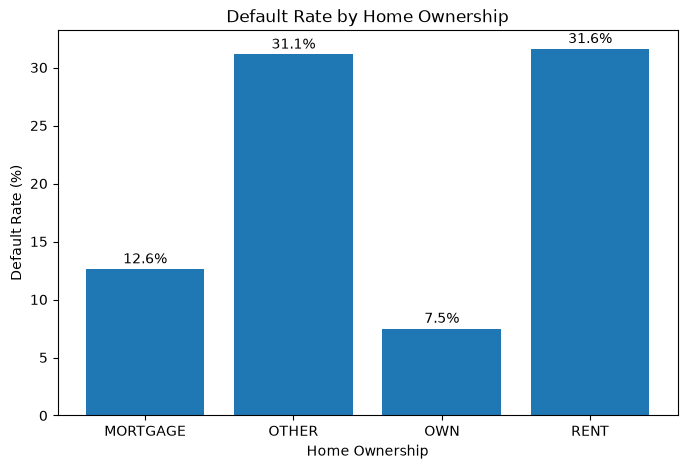

In [26]:
plt.figure(figsize=(8,5))

plt.bar(
    home_default["person_home_ownership"],
    home_default["default_rate"]
)

plt.xlabel("Home Ownership")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Home Ownership")

for i, value in enumerate(home_default["default_rate"]):
    plt.text(i, value + 0.5, f"{value:.1f}%", ha="center")

plt.show()

### Key Business Insight

Borrowers who owned their homes exhibited the lowest observed default rate (7.5%), while renters showed the highest (31.6%). This suggests that home ownership is associated with lower observed credit risk in this dataset.

### Business Recommendation

Home ownership provides valuable information about borrower financial stability and should be retained as a predictive feature. Incorporating this variable into the model can improve borrower risk segmentation and support more informed credit decisions.

### Loan Purpose Analysis

Default rates are compared across different loan purposes to identify loan categories associated with higher credit risk.

In [33]:
intent_default = (
    df.groupby("loan_intent")["loan_status"]
    .agg(["count", "mean"])
    .reset_index()
)

intent_default["default_rate"] = (
    intent_default["mean"] * 100
).round(2)

intent_default = intent_default.sort_values(
    "default_rate",
    ascending=False
)

intent_default[
    [
        "loan_intent",
        "count",
        "default_rate"
    ]
]

,loan_intent,count,default_rate
0,DEBTCONSOLIDATION,5189,28.68
3,MEDICAL,6042,26.76
2,HOMEIMPROVEMENT,3594,26.15
4,PERSONAL,5496,19.89
1,EDUCATION,6409,17.26
5,VENTURE,5679,14.86


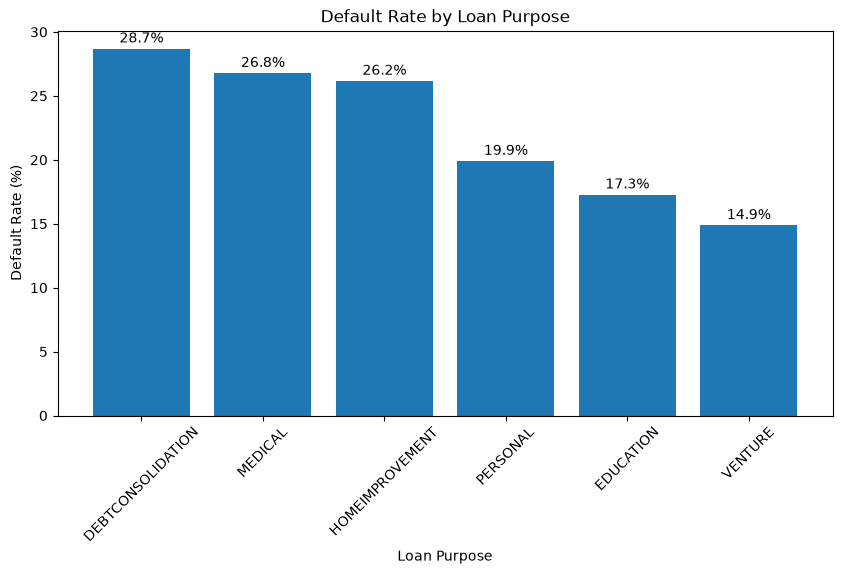

In [28]:
plt.figure(figsize=(10,5))

plt.bar(
    intent_default["loan_intent"],
    intent_default["default_rate"]
)

plt.xticks(rotation=45)

plt.xlabel("Loan Purpose")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Loan Purpose")

for i, value in enumerate(intent_default["default_rate"]):
    plt.text(i, value + 0.5, f"{value:.1f}%", ha="center")

plt.show()

### Key Business Insight

Default rates varied considerably across loan purposes. Debt consolidation, medical, and home improvement loans exhibited the highest observed default rates, whereas education and venture loans showed comparatively lower default rates. This indicates that borrower intent influences observed credit risk.

### Business Recommendation

Loan purpose should be included as a model feature because different borrowing objectives exhibit different levels of default risk. Understanding these patterns can help lenders refine underwriting strategies and improve risk-based decision making.

In [34]:
history_default = (
    df.groupby("cb_person_default_on_file")["loan_status"]
    .agg(["count", "mean"])
    .reset_index()
)

history_default["default_rate"] = (
    history_default["mean"] * 100
).round(2)

history_default[
    [
        "cb_person_default_on_file",
        "count",
        "default_rate"
    ]
]

,cb_person_default_on_file,count,default_rate
0,N,26680,18.44
1,Y,5729,37.86


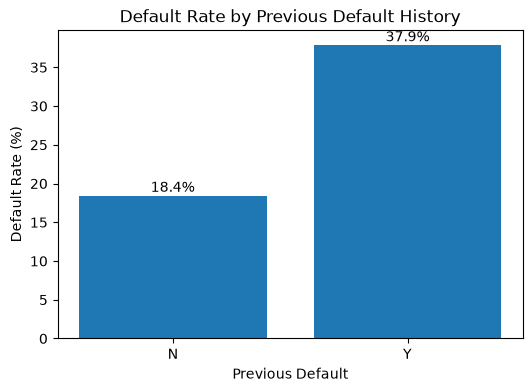

In [30]:
plt.figure(figsize=(6,4))

plt.bar(
    history_default["cb_person_default_on_file"],
    history_default["default_rate"]
)

plt.xlabel("Previous Default")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Previous Default History")

for i, value in enumerate(history_default["default_rate"]):
    plt.text(i, value + 0.5, f"{value:.1f}%", ha="center")

plt.show()

### Key Business Insight

Borrowers with a previous default history exhibited an observed default rate of approximately 37.9%, compared with 18.4% for borrowers without previous defaults. Historical repayment behavior is therefore strongly associated with future default risk.

### Business Recommendation

Previous default history is one of the most informative predictors of credit risk. Including this feature enables the model to better distinguish borrowers with elevated default probability and supports more accurate Probability of Default (PD) estimation.

# Data Preprocessing

Before model development, missing values are handled and categorical variables are converted into numerical format suitable for Logistic Regression.

In [35]:
# Fill missing employment length with median

df["person_emp_length"] = df["person_emp_length"].fillna(
    df["person_emp_length"].median()
)

# Fill missing interest rate with median

df["loan_int_rate"] = df["loan_int_rate"].fillna(
    df["loan_int_rate"].median()
)

print(df.isnull().sum())

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [36]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (32409, 11)
Target Shape : (32409,)


In [37]:
X = pd.get_dummies(
    X,
    drop_first=True
)

print("Encoded Shape :", X.shape)

X.head()

Encoded Shape : (32409, 22)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
1,21,9600,5.0,1000,11.14,0.10,2,False,True,False,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,0.57,3,False,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,0.53,2,False,False,True,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,0.55,4,False,False,True,...,True,False,False,False,True,False,False,False,False,True
5,21,9900,2.0,2500,7.14,0.25,2,False,True,False,...,False,False,True,False,False,False,False,False,False,False


In [38]:
X.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B',
       'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F',
       'loan_grade_G', 'cb_person_default_on_file_Y'],
      dtype='str')

## Data Preprocessing Summary

Missing values were imputed using median values to preserve dataset size. Categorical variables were transformed using one-hot encoding, making the dataset compatible with Logistic Regression while avoiding multicollinearity by dropping the first category.

# Model Development

The dataset is divided into training and testing subsets to evaluate model performance on unseen data. An 80:20 split is used while preserving the original class distribution through stratified sampling.

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (25927, 22)
Testing Features  : (6482, 22)
Training Target   : (25927,)
Testing Target    : (6482,)


# Logistic Regression Model

A Logistic Regression classifier is trained to estimate the Probability of Default (PD). Logistic Regression is widely used in credit risk modeling because it produces interpretable probability estimates and serves as the foundation of traditional credit scorecards.

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale numerical features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


# Probability of Default Prediction

The trained Logistic Regression model is used to predict both the borrower class (Default / Non-Default) and the Probability of Default (PD) for unseen observations.

In [42]:
# Predict borrower class

y_pred = model.predict(X_test_scaled)

# Predict Probability of Default (PD)

y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Prediction Shape :", y_pred.shape)
print("Probability Shape :", y_prob.shape)

print("\nFirst 10 predicted probabilities:\n")

y_prob[:10]

Prediction Shape : (6482,)
Probability Shape : (6482,)

First 10 predicted probabilities:



array([0.12746854, 0.0771491 , 0.39244839, 0.18164944, 0.76320218,
       0.0062009 , 0.62974221, 0.10124227, 0.03396986, 0.08520422])

## Sample Prediction Results

The table below compares actual borrower outcomes against the predictions generated by the Logistic Regression model.

In [43]:
prediction_df = pd.DataFrame({

    "Actual_Default": y_test.values,

    "Predicted_Default": y_pred,

    "Probability_of_Default": y_prob.round(4)

})

prediction_df.head(10)

,Actual_Default,Predicted_Default,Probability_of_Default
0,0,0,0.1275
1,1,0,0.0771
2,0,0,0.3924
3,0,0,0.1816
4,1,1,0.7632
5,0,0,0.0062
6,1,1,0.6297
7,0,0,0.1012
8,0,0,0.0340
9,0,0,0.0852


# Model Evaluation

The Logistic Regression model is evaluated using multiple classification metrics to assess its predictive performance. In addition to Accuracy, Precision, Recall, and F1-Score, the model is evaluated using ROC-AUC, Confusion Matrix, KS Statistic, and Gini Coefficient, which are widely used in credit risk modeling.

In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt

In [45]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))
print("ROC AUC  :", round(auc,4))

Accuracy : 0.8645
Precision: 0.7581
Recall   : 0.5592
F1 Score : 0.6437
ROC AUC  : 0.8703


## Model Performance Metrics

The following metrics summarize the predictive performance of the Logistic Regression model on the unseen test dataset.

In [46]:
metrics_df = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]

})

metrics_df["Value"] = metrics_df["Value"].round(4)

metrics_df

,Metric,Value
0,Accuracy,0.8645
1,Precision,0.7581
2,Recall,0.5592
3,F1 Score,0.6437
4,ROC AUC,0.8703


## Confusion Matrix

The confusion matrix summarizes the model's classification performance by comparing predicted loan defaults against the actual outcomes.

In [47]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4811  253]
 [ 625  793]]


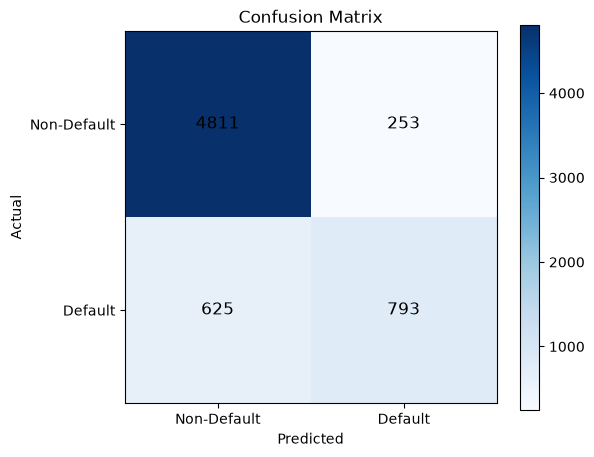

In [48]:
plt.figure(figsize=(6,5))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Non-Default","Default"])
plt.yticks([0,1], ["Non-Default","Default"])

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="black",
            fontsize=12
        )

plt.show()

### Business Interpretation

The confusion matrix provides a detailed breakdown of correct and incorrect loan default predictions. It helps evaluate how effectively the model identifies high-risk borrowers while minimizing false approvals and unnecessary loan rejections.

## ROC Curve

The Receiver Operating Characteristic (ROC) Curve evaluates the model's ability to distinguish between default and non-default borrowers across different classification thresholds. The Area Under the Curve (AUC) summarizes the model's discriminatory power.

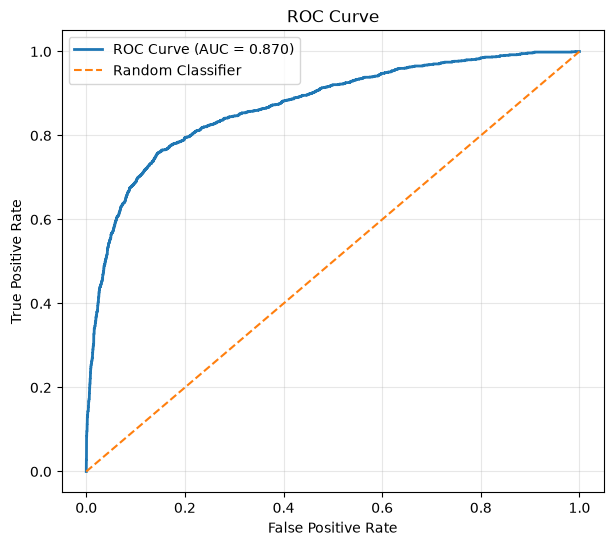

In [49]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC Curve (AUC = {auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Business Interpretation

The ROC Curve demonstrates the model's ability to rank high-risk borrowers ahead of low-risk borrowers across all decision thresholds. The achieved ROC-AUC of approximately **0.87** indicates strong discriminatory performance, making the model suitable for credit risk assessment and Probability of Default (PD) estimation.

## Kolmogorov-Smirnov (KS) Statistic

The Kolmogorov-Smirnov (KS) Statistic measures the maximum separation between the cumulative distributions of defaulting and non-defaulting borrowers. It is one of the most widely used validation metrics in credit risk modeling because it quantifies how effectively the model distinguishes risky borrowers from good borrowers.

In [50]:
from sklearn.metrics import roc_curve

# Calculate ROC components
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# KS Statistic
ks = max(tpr - fpr)

print(f"KS Statistic : {ks:.4f}")

KS Statistic : 0.6136


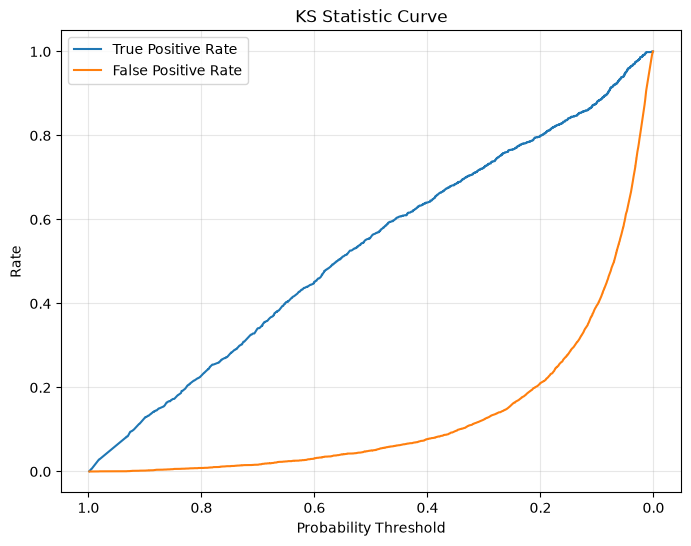

In [51]:
plt.figure(figsize=(8,6))

plt.plot(thresholds, tpr, label="True Positive Rate")
plt.plot(thresholds, fpr, label="False Positive Rate")

plt.gca().invert_xaxis()

plt.xlabel("Probability Threshold")
plt.ylabel("Rate")
plt.title("KS Statistic Curve")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Business Interpretation

The KS Statistic represents the maximum separation between cumulative default and non-default distributions. Higher KS values indicate stronger discriminatory power. In credit risk modeling, a KS value above **0.30** is generally considered acceptable, while values above **0.40** indicate a strong predictive model.

## Gini Coefficient

The Gini Coefficient is another widely accepted measure of model discrimination in credit risk modeling. It is directly derived from the ROC-AUC and provides an intuitive measure of the model's ranking capability.

In [52]:
gini = (2 * auc) - 1

print(f"Gini Coefficient : {gini:.4f}")

Gini Coefficient : 0.7406


In [53]:
validation_df = pd.DataFrame({

    "Metric":[
        "ROC AUC",
        "KS Statistic",
        "Gini Coefficient"
    ],

    "Value":[
        auc,
        ks,
        gini
    ]

})

validation_df["Value"] = validation_df["Value"].round(4)

validation_df

,Metric,Value
0,ROC AUC,0.8703
1,KS Statistic,0.6136
2,Gini Coefficient,0.7406


### Business Interpretation

The model achieved a strong ROC-AUC, KS Statistic, and Gini Coefficient, indicating effective separation between low-risk and high-risk borrowers. These validation metrics demonstrate that the Logistic Regression scorecard possesses strong discriminatory power and is suitable for estimating Probability of Default (PD) in a credit risk environment.

# Feature Importance

Since Logistic Regression is an interpretable model, the learned coefficients indicate how strongly each feature influences the probability of borrower default. Positive coefficients increase default risk, while negative coefficients reduce default risk.

In [54]:
feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Coefficient": model.coef_[0]

})

feature_importance["Absolute"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    "Absolute",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute
5,loan_percent_income,1.444317,1.444317
17,loan_grade_D,0.796209,0.796209
3,loan_amnt,-0.699269,0.699269
18,loan_grade_E,0.472608,0.472608
8,person_home_ownership_OWN,-0.465356,0.465356
9,person_home_ownership_RENT,0.419662,0.419662
14,loan_intent_VENTURE,-0.415572,0.415572
10,loan_intent_EDUCATION,-0.344760,0.344760
20,loan_grade_G,0.299762,0.299762
19,loan_grade_F,0.275360,0.275360


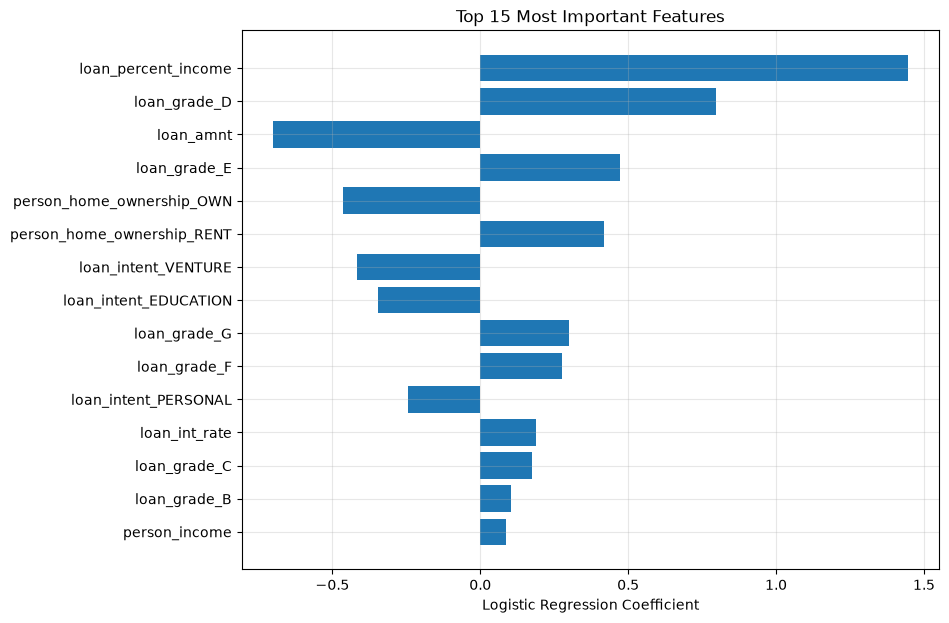

In [55]:
top_features = feature_importance.head(15)

plt.figure(figsize=(9,7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Top 15 Most Important Features")
plt.xlabel("Logistic Regression Coefficient")

plt.gca().invert_yaxis()

plt.grid(alpha=0.3)

plt.show()

## Business Interpretation

The model coefficients indicate the direction and magnitude of each variable's influence on default probability. Features with larger absolute coefficients contribute more strongly to credit risk prediction. This interpretability makes Logistic Regression highly suitable for regulated financial institutions and scorecard development.

## Project Limitations

- Logistic Regression assumes a linear relationship between predictors and log-odds.
- Feature interactions are not modeled.
- The dataset is publicly available and may not reflect current lending behavior.
- Future improvements include XGBoost, LightGBM, WOE binning, IV analysis and Scorecard scaling.

# Project Conclusion

This project successfully developed an end-to-end **Probability of Default (PD) model** using **Logistic Regression** to estimate borrower credit risk. The workflow covered data quality assessment, exploratory data analysis, feature engineering, data preprocessing, model development, prediction, and performance evaluation.

Business-driven exploratory analysis identified **Loan Grade, Previous Default History, Loan Purpose, Home Ownership, Interest Rate, and Loan Percent Income** as key factors influencing borrower default behavior. These insights demonstrate how borrower characteristics can be used to improve credit risk assessment and lending decisions.

The final model achieved strong predictive performance with a **ROC-AUC of 0.8703**, **KS Statistic of 0.6136**, and **Gini Coefficient of 0.7406**, indicating excellent discriminatory power between low-risk and high-risk borrowers. Additional evaluation using Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and Probability of Default predictions further confirmed the model's effectiveness.

Overall, this project demonstrates a complete credit risk modeling workflow similar to those used in banking and fintech organizations for borrower risk assessment. While Logistic Regression provides an interpretable and reliable baseline model, future improvements may include **Weight of Evidence (WOE) transformation, Information Value (IV) analysis, Scorecard Scaling (PDO), Risk Banding, and advanced machine learning models such as XGBoost or LightGBM** to further enhance predictive performance and business applicability.

## Thank You

Thank you for reviewing this project.

This notebook demonstrates an end-to-end Credit Risk Scorecard workflow, covering data preprocessing, business-driven exploratory analysis, Probability of Default (PD) modeling, and model evaluation using industry-relevant validation metrics.

The project is intended to showcase practical credit risk analytics skills applicable to banking and fintech environments.